# Data analysis assignment — 30 intermediate concept-building questions

Each question teaches one additional idea instead of only repeating syntax. Try the task before revealing/running the solution cell.

> **Explain it like I am five:** These are 30 small levels in a game. Each level gives you one new tool, shows why it matters, and lets you use it immediately.

## How to study

1. Read the question and the tiny explanation.
2. Predict the shape, columns, or result.
3. Write your own solution in a new cell.
4. Run the provided solution.
5. Change one input and explain what changes.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
rng = np.random.default_rng(30)


In [2]:
from pathlib import Path

def data_path(filename):
    """Find a course data file whether Jupyter starts in the repo or lesson folder."""
    current = Path.cwd().resolve()
    lesson_parts = ("Complete-Python-Bootcamp-main", "10-Data Analysis With Python")
    candidates = [current / filename, current.joinpath(*lesson_parts, filename)]
    for parent in current.parents:
        candidates.extend([parent / filename, parent.joinpath(*lesson_parts, filename)])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename!r}. Start Jupyter inside this repository.")


In [3]:
sales_assignment = pd.read_csv(data_path('sales_data.csv'), parse_dates=['Date'])
cleaning_assignment = pd.read_csv(data_path('data.csv'), parse_dates=['Date'])

print("sales rows:", len(sales_assignment))
print("cleaning rows:", len(cleaning_assignment))


sales rows: 240
cleaning rows: 50


## 1. Reproducible random arrays

**Task:** Create a 4×5 array of integers from 10 through 99 using `default_rng(101)`. Recreate it with a second generator using the same seed and prove both arrays are equal.

**Explain it like I am five:** A seed is a recipe number. Two cooks following the same recipe make the same practice data, which makes debugging and grading fair.

**Before running:** predict the important output shape, row count, or interpretation.


In [4]:
first_rng = np.random.default_rng(101)
second_rng = np.random.default_rng(101)
first_array = first_rng.integers(10, 100, size=(4, 5))
second_array = second_rng.integers(10, 100, size=(4, 5))

print(first_array)
print("same values:", np.array_equal(first_array, second_array))


[[37 94 72 42 22]
 [80 45 63 65 36]
 [42 93 79 88 22]
 [42 16 97 69 30]]
same values: True


## 2. Axes and row/column summaries

**Task:** For a 3×4 score array, calculate one mean per column and one maximum per row. State the output shapes before running.

**Explain it like I am five:** An axis is the direction we fold the table. Folding rows with `axis=0` leaves columns; folding columns with `axis=1` leaves rows.

**Before running:** predict the important output shape, row count, or interpretation.


In [5]:
scores = np.array([[80, 70, 90, 85], [60, 75, 82, 78], [95, 88, 91, 93]])
column_means = scores.mean(axis=0)
row_maximums = scores.max(axis=1)

print("column means:", column_means, "shape:", column_means.shape)
print("row maximums:", row_maximums, "shape:", row_maximums.shape)


column means: [78.33333333 77.66666667 87.66666667 85.33333333] shape: (4,)
row maximums: [90 82 95] shape: (3,)


## 3. Broadcasting a discount

**Task:** Apply three different percentage discounts to every row of a 2×3 price array without writing a loop.

**Explain it like I am five:** Broadcasting is an invisible photocopier: NumPy acts as if the three discounts were copied into every row.

**Before running:** predict the important output shape, row count, or interpretation.


In [6]:
prices = np.array([[100.0, 200.0, 300.0], [150.0, 250.0, 350.0]])
discounts = np.array([0.10, 0.20, 0.05])
final_prices = prices * (1 - discounts)

print(final_prices)


[[ 90.  160.  285. ]
 [135.  200.  332.5]]


## 4. Cap outliers with `clip`

**Task:** Limit sensor readings to the valid range 0–100 and count how many original values were outside that range.

**Explain it like I am five:** `clip` is a fence. Values inside stay where they are; values outside move to the nearest fence edge.

**Before running:** predict the important output shape, row count, or interpretation.


In [7]:
readings = np.array([-5, 12, 48, 105, 88, 140, 0])
outside_count = ((readings < 0) | (readings > 100)).sum()
valid_readings = np.clip(readings, 0, 100)

print("outside count:", outside_count)
print("capped:", valid_readings)


outside count: 3
capped: [  0  12  48 100  88 100   0]


## 5. Label values with `where` and `select`

**Task:** Label exam scores as `Pass` or `Retry`, then create `High`, `Medium`, and `Low` bands.

**Explain it like I am five:** The condition is a row of yes/no traffic lights. `where` chooses one of two roads; `select` can choose among several roads.

**Before running:** predict the important output shape, row count, or interpretation.


In [8]:
exam_scores = np.array([32, 48, 67, 81, 95])
pass_labels = np.where(exam_scores >= 40, 'Pass', 'Retry')
bands = np.select(
    [exam_scores >= 80, exam_scores >= 50],
    ['High', 'Medium'],
    default='Low'
)

print(pass_labels)
print(bands)


['Retry' 'Pass' 'Pass' 'Pass' 'Pass']
['Low' 'Low' 'Medium' 'High' 'High']


## 6. Missing values and nan-aware statistics

**Task:** Find the mean of an array containing `np.nan`, fill missing entries with that mean, and verify no missing values remain.

**Explain it like I am five:** A missing value is an empty cup. `nanmean` measures only filled cups, and the mask tells us which cups need filling.

**Before running:** predict the important output shape, row count, or interpretation.


In [9]:
measurements = np.array([12.0, np.nan, 18.0, 20.0, np.nan])
mean_value = np.nanmean(measurements)
filled = np.where(np.isnan(measurements), mean_value, measurements)

print("mean:", mean_value)
print("filled:", filled)
print("missing left:", np.isnan(filled).sum())


mean: 16.666666666666668
filled: [12.         16.66666667 18.         20.         16.66666667]
missing left: 0


## 7. Standardization with a safety check

**Task:** Write a function that returns z-scores and raises a clear error when every value is identical.

**Explain it like I am five:** Standardization moves the class average to zero and measures how many class-sized steps each value is away. If nobody differs, the step size is zero.

**Before running:** predict the important output shape, row count, or interpretation.


In [10]:
def standardize(values):
    values = np.asarray(values, dtype=float)
    spread = values.std()
    if spread == 0:
        raise ValueError("Cannot standardize values with zero standard deviation")
    return (values - values.mean()) / spread


z_scores = standardize([10, 20, 30, 40])
print(z_scores)
print("mean/std:", z_scores.mean(), z_scores.std())


[-1.34164079 -0.4472136   0.4472136   1.34164079]
mean/std: 0.0 1.0


## 8. Top-k positions with `argsort`

**Task:** Find the indices and values of the three largest scores without sorting the original array in place.

**Explain it like I am five:** `argsort` sorts the name tags instead of moving the children. The returned positions tell us where the ranked values came from.

**Before running:** predict the important output shape, row count, or interpretation.


In [11]:
scores = np.array([72, 91, 65, 88, 95, 79])
top_positions = np.argsort(scores)[-3:][::-1]

print("positions:", top_positions)
print("top scores:", scores[top_positions])
print("original unchanged:", scores)


positions: [4 1 3]
top scores: [95 91 88]
original unchanged: [72 91 65 88 95 79]


## 9. Stack arrays with compatible shapes

**Task:** Join two 2×2 arrays vertically and horizontally. Explain the resulting shapes.

**Explain it like I am five:** Vertical stacking adds floors to a building; horizontal stacking adds rooms beside the existing rooms.

**Before running:** predict the important output shape, row count, or interpretation.


In [12]:
left = np.array([[1, 2], [3, 4]])
right = np.array([[5, 6], [7, 8]])

vertical = np.vstack([left, right])
horizontal = np.hstack([left, right])
print("vertical", vertical.shape, "\n", vertical)
print("horizontal", horizontal.shape, "\n", horizontal)


vertical (4, 2) 
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
horizontal (2, 4) 
 [[1 2 5 6]
 [3 4 7 8]]


## 10. Weighted totals with matrix multiplication

**Task:** Use `@` to calculate two customers' total basket costs from a quantity matrix and a price vector.

**Explain it like I am five:** Each customer row meets the price column. Multiply matching items and add them to get one bill per customer.

**Before running:** predict the important output shape, row count, or interpretation.


In [13]:
quantities = np.array([[2, 1, 3], [1, 4, 0]])
unit_prices = np.array([10.0, 5.0, 2.0])
totals = quantities @ unit_prices

print("customer totals:", totals)


customer totals: [31. 30.]


## 11. Build and validate a DataFrame schema

**Task:** Create a student table using nullable string, integer, and boolean dtypes. Assert that student IDs are unique.

**Explain it like I am five:** A schema is a seating plan: it says which column exists and what kind of value belongs in each seat.

**Before running:** predict the important output shape, row count, or interpretation.


In [14]:
students = pd.DataFrame({
    'student_id': pd.Series(['S01', 'S02', 'S03'], dtype='string'),
    'attempts': pd.Series([1, None, 2], dtype='Int64'),
    'passed': pd.Series([True, None, False], dtype='boolean')
})

assert students['student_id'].is_unique
print(students)
print(students.dtypes)


  student_id  attempts  passed
0        S01         1    True
1        S02      <NA>    <NA>
2        S03         2   False
student_id     string
attempts        Int64
passed        boolean
dtype: object


## 12. `loc` vs. `iloc` after changing the index

**Task:** Set transaction IDs as the index. Select one row by ID with `loc` and the first row by position with `iloc`.

**Explain it like I am five:** `loc` asks for the child named on the register. `iloc` asks for the child sitting in seat number zero.

**Before running:** predict the important output shape, row count, or interpretation.


In [15]:
indexed_sales = sales_assignment.set_index('Transaction ID')
first_id = indexed_sales.index[0]

print("by label:\n", indexed_sales.loc[first_id, ['Product Name', 'Total Revenue']])
print("\nby position:\n", indexed_sales.iloc[0][['Product Name', 'Total Revenue']])


by label:
 Product Name     iPhone 14 Pro
Total Revenue          1999.98
Name: 10001, dtype: object

by position:
 Product Name     iPhone 14 Pro
Total Revenue          1999.98
Name: 10001, dtype: object


## 13. Clean text and extract parts

**Task:** Normalize messy email text and extract the username and domain into separate columns.

**Explain it like I am five:** String methods are a washing line: trim the edges, make case consistent, then separate useful pieces.

**Before running:** predict the important output shape, row count, or interpretation.


In [16]:
contacts = pd.DataFrame({'email': [' Asha@Example.COM ', 'noor@test.org', 'invalid']})
contacts['clean_email'] = contacts['email'].str.strip().str.lower()
extracted = contacts['clean_email'].str.extract(r'(?P<username>[^@]+)@(?P<domain>.+)')
contacts = pd.concat([contacts, extracted], axis=1)

print(contacts)


                email       clean_email username       domain
0   Asha@Example.COM   asha@example.com     asha  example.com
1       noor@test.org     noor@test.org     noor     test.org
2             invalid           invalid      NaN          NaN


## 14. Parse dates and inspect failures

**Task:** Convert mixed date text with `errors='coerce'`, count invalid dates, and extract valid month names.

**Explain it like I am five:** A strict calendar clerk turns readable dates into calendar objects and marks nonsense as missing so we can investigate it.

**Before running:** predict the important output shape, row count, or interpretation.


In [17]:
raw_dates = pd.Series(['2025-01-05', 'not-a-date', '2025-03-12'])
parsed_dates = pd.to_datetime(raw_dates, errors='coerce')

print("invalid:", parsed_dates.isna().sum())
print("months:", parsed_dates.dt.month_name().tolist())


invalid: 1
months: ['January', nan, 'March']


## 15. Diagnose and remove duplicates

**Task:** Create duplicate order rows, identify every member of a duplicate group, then keep the latest row per order ID.

**Explain it like I am five:** Duplicates are photocopied forms. Before throwing one away, choose the rule that tells you which copy is the keeper.

**Before running:** predict the important output shape, row count, or interpretation.


In [18]:
orders = pd.DataFrame({
    'order_id': [1, 1, 2, 3, 3],
    'updated': pd.to_datetime(['2025-01-01', '2025-01-03', '2025-01-02', '2025-01-01', '2025-01-04']),
    'status': ['New', 'Shipped', 'New', 'New', 'Cancelled']
})
duplicate_rows = orders[orders.duplicated('order_id', keep=False)]
latest_orders = (
    orders.sort_values('updated')
    .drop_duplicates('order_id', keep='last')
    .sort_values('order_id')
)

print("duplicates:\n", duplicate_rows)
print("\nlatest:\n", latest_orders)


duplicates:
    order_id    updated     status
0         1 2025-01-01        New
1         1 2025-01-03    Shipped
3         3 2025-01-01        New
4         3 2025-01-04  Cancelled

latest:
    order_id    updated     status
1         1 2025-01-03    Shipped
2         2 2025-01-02        New
4         3 2025-01-04  Cancelled


## 16. Fill missing values within groups

**Task:** Fill missing `Sales` using the median for each product and verify the missing count afterward.

**Explain it like I am five:** Different classrooms may have different typical scores. A group median borrows from the most relevant classmates, not the entire school.

**Before running:** predict the important output shape, row count, or interpretation.


In [19]:
group_filled = cleaning_assignment.copy()
product_median = group_filled.groupby('Product')['Sales'].transform('median')
group_filled['Sales'] = group_filled['Sales'].fillna(product_median)

print("missing before:", cleaning_assignment['Sales'].isna().sum())
print("missing after:", group_filled['Sales'].isna().sum())
print(group_filled[['Product', 'Sales']].head(10))


missing before: 4
missing after: 0
    Product  Sales
0  Product1  754.0
1  Product3  110.0
2  Product2  398.0
3  Product1  522.0
4  Product3  869.0
5  Product3  192.0
6  Product1  936.0
7  Product1  488.0
8  Product3  772.0
9  Product2  834.0


## 17. Named group aggregation

**Task:** Create a region report containing order count, total units, average revenue, and maximum revenue, sorted by total revenue.

**Explain it like I am five:** Groupby puts receipts into region baskets. Named aggregation tells each basket which answers to write on its label.

**Before running:** predict the important output shape, row count, or interpretation.


In [20]:
region_report = (
    sales_assignment.groupby('Region', as_index=False)
    .agg(
        Orders=('Transaction ID', 'count'),
        Units=('Units Sold', 'sum'),
        Average_Revenue=('Total Revenue', 'mean'),
        Maximum_Revenue=('Total Revenue', 'max'),
        Total_Revenue=('Total Revenue', 'sum')
    )
    .sort_values('Total_Revenue', ascending=False)
)
print(region_report.round(2))


          Region  Orders  Units  Average_Revenue  Maximum_Revenue  \
2  North America      80    180           460.55          3899.99   
0           Asia      80    233           280.69          1895.00   
1         Europe      80    105           265.85          2599.98   

   Total_Revenue  
2       36844.34  
0       22455.45  
1       21268.06  


## 18. Row share with `transform`

**Task:** Calculate each transaction's percentage of its region's revenue and verify percentages sum to 100% per region.

**Explain it like I am five:** `transform` writes the region basket total beside every receipt, so each receipt can measure its slice of the basket.

**Before running:** predict the important output shape, row count, or interpretation.


In [21]:
share_table = sales_assignment.assign(
    Region_Total=lambda table: table.groupby('Region')['Total Revenue'].transform('sum')
).assign(
    Region_Share=lambda table: table['Total Revenue'] / table['Region_Total']
)

check = share_table.groupby('Region')['Region_Share'].sum()
print(share_table[['Region', 'Total Revenue', 'Region_Total', 'Region_Share']].head())
print("\nshare check:\n", check)


          Region  Total Revenue  Region_Total  Region_Share
0  North America        1999.98      36844.34      0.054282
1         Europe         499.99      21268.06      0.023509
2           Asia         209.97      22455.45      0.009351
3  North America          63.96      36844.34      0.001736
4         Europe          89.99      21268.06      0.004231

share check:
 Region
Asia             1.0
Europe           1.0
North America    1.0
Name: Region_Share, dtype: float64


## 19. Pivot table with totals

**Task:** Build a product-category by region revenue table, fill missing combinations with zero, and include row/column totals.

**Explain it like I am five:** A pivot table turns basket labels into a grid. Margins add the final total row and total column.

**Before running:** predict the important output shape, row count, or interpretation.


In [22]:
revenue_pivot = pd.pivot_table(
    sales_assignment,
    index='Product Category',
    columns='Region',
    values='Total Revenue',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='All Regions'
)
print(revenue_pivot.round(2))


Region                Asia    Europe  North America  All Regions
Product Category                                                
Beauty Products       0.00   2621.90           0.00      2621.90
Books                 0.00      0.00        1861.93      1861.93
Clothing           8128.93      0.00           0.00      8128.93
Electronics           0.00      0.00       34982.41     34982.41
Home Appliances       0.00  18646.16           0.00     18646.16
Sports            14326.52      0.00           0.00     14326.52
All Regions       22455.45  21268.06       36844.34     80567.85


## 20. Melt a wide report into tidy rows

**Task:** Convert a quarterly wide table into columns `Product`, `Quarter`, and `Revenue`.

**Explain it like I am five:** Wide data keeps quarters in separate drawers. `melt` empties those drawers into one labeled Quarter column and one Revenue column.

**Before running:** predict the important output shape, row count, or interpretation.


In [23]:
quarterly_wide = pd.DataFrame({
    'Product': ['A', 'B'],
    'Q1': [100, 150],
    'Q2': [120, 140],
    'Q3': [130, 170]
})
quarterly_long = quarterly_wide.melt(
    id_vars='Product',
    var_name='Quarter',
    value_name='Revenue'
)
print(quarterly_long)


  Product Quarter  Revenue
0       A      Q1      100
1       B      Q1      150
2       A      Q2      120
3       B      Q2      140
4       A      Q3      130
5       B      Q3      170


## 21. Merge with relationship validation

**Task:** Merge customers with orders using `validate='one_to_many'`. Explain why reversing the validation would fail.

**Explain it like I am five:** One customer card can match many order slips. Validation checks that the relationship follows that rule.

**Before running:** predict the important output shape, row count, or interpretation.


In [24]:
customers = pd.DataFrame({'customer_id': [1, 2, 3], 'name': ['Asha', 'Noor', 'Ravi']})
orders = pd.DataFrame({'order_id': [10, 11, 12, 13], 'customer_id': [1, 1, 2, 3], 'amount': [50, 75, 40, 90]})

customer_orders = customers.merge(
    orders,
    on='customer_id',
    how='left',
    validate='one_to_many'
)
print(customer_orders)


   customer_id  name  order_id  amount
0            1  Asha        10      50
1            1  Asha        11      75
2            2  Noor        12      40
3            3  Ravi        13      90


## 22. Find unmatched keys with an anti-join pattern

**Task:** Use an outer merge with `indicator=True` to find IDs that appear only on the left or only on the right.

**Explain it like I am five:** The indicator is a colored stamp saying 'both books,' 'left book only,' or 'right book only.'

**Before running:** predict the important output shape, row count, or interpretation.


In [25]:
planned = pd.DataFrame({'item_id': [1, 2, 3, 4]})
actual = pd.DataFrame({'item_id': [2, 3, 5]})
audit = planned.merge(actual, on='item_id', how='outer', indicator=True)

print(audit)
print("\nunmatched:\n", audit.loc[audit['_merge'] != 'both'])


   item_id      _merge
0        1   left_only
1        2        both
2        3        both
3        4   left_only
4        5  right_only

unmatched:
 

   item_id      _merge
0        1   left_only
3        4   left_only
4        5  right_only


## 23. Concatenate batches with provenance

**Task:** Combine January and February tables while keeping a new index level that records the source month.

**Explain it like I am five:** Provenance is a luggage tag. After stacking batches, the tag remembers which suitcase each row came from.

**Before running:** predict the important output shape, row count, or interpretation.


In [26]:
january = pd.DataFrame({'order': [1, 2], 'amount': [100, 120]})
february = pd.DataFrame({'order': [3, 4], 'amount': [90, 140]})
combined = pd.concat(
    {'January': january, 'February': february},
    names=['Source_Month', 'Original_Row']
)

print(combined)
print("\nas columns:\n", combined.reset_index())


                           order  amount
Source_Month Original_Row               
January      0                 1     100
             1                 2     120
February     0                 3      90
             1                 4     140



as columns:
   Source_Month  Original_Row  order  amount
0      January             0      1     100
1      January             1      2     120
2     February             0      3      90
3     February             1      4     140


## 24. Build a readable method chain

**Task:** From the sales data, keep orders above 500, add revenue per unit, summarize mean revenue per unit by category, and sort descending.

**Explain it like I am five:** A method chain is a recipe read from top to bottom. Each step should do one understandable job.

**Before running:** predict the important output shape, row count, or interpretation.


In [27]:
chained_report = (
    sales_assignment.loc[sales_assignment['Total Revenue'] > 500]
    .assign(Revenue_Per_Unit=lambda table: table['Total Revenue'] / table['Units Sold'])
    .groupby('Product Category', as_index=False)
    .agg(Mean_Revenue_Per_Unit=('Revenue_Per_Unit', 'mean'))
    .sort_values('Mean_Revenue_Per_Unit', ascending=False)
)
print(chained_report.round(2))


  Product Category  Mean_Revenue_Per_Unit
1      Electronics                1079.45
3           Sports                 703.56
2  Home Appliances                 607.65
0         Clothing                  89.99


## 25. Ordered categorical data

**Task:** Create Low/Medium/High order-size bands and sort them in logical rather than alphabetical order.

**Explain it like I am five:** An ordered category is a staircase. It remembers that Medium is above Low and below High.

**Before running:** predict the important output shape, row count, or interpretation.


In [28]:
order_type = pd.CategoricalDtype(['Low', 'Medium', 'High'], ordered=True)
order_sizes = pd.cut(
    sales_assignment['Total Revenue'],
    bins=[0, 250, 1000, float('inf')],
    labels=['Low', 'Medium', 'High']
).astype(order_type)
size_summary = (
    sales_assignment.assign(Order_Size=order_sizes)
    .groupby('Order_Size', observed=False)
    .agg(Orders=('Transaction ID', 'count'), Revenue=('Total Revenue', 'sum'))
)
print(size_summary)


            Orders   Revenue
Order_Size                  
Low            149  15175.73
Medium          74  35398.37
High            17  29993.75


## 26. Monthly resampling

**Task:** Convert transactions into monthly revenue totals and find the month with the highest revenue.

**Explain it like I am five:** Resampling pours many daily drops into monthly buckets. Each bucket receives one total.

**Before running:** predict the important output shape, row count, or interpretation.


In [29]:
monthly_revenue = (
    sales_assignment.set_index('Date')['Total Revenue']
    .sort_index()
    .resample('ME')
    .sum()
)
print(monthly_revenue)
print("highest month:", monthly_revenue.idxmax().strftime('%Y-%m'))


Date
2024-01-31    14548.32
2024-02-29    10803.37
2024-03-31    12849.24
2024-04-30    12451.69
2024-05-31     8455.49
2024-06-30     7384.55
2024-07-31     6797.08
2024-08-31     7278.11
Freq: ME, Name: Total Revenue, dtype: float64
highest month: 2024-01


## 27. Lagged and rolling features without future leakage

**Task:** Create previous-month revenue and a three-month average that uses only earlier months, not the current or future month.

**Explain it like I am five:** For an honest prediction, the student may read yesterday's pages but not tomorrow's answer sheet. `shift(1)` moves history into the current row.

**Before running:** predict the important output shape, row count, or interpretation.


In [30]:
time_features = monthly_revenue.rename('Revenue').to_frame()
time_features['Previous_Month'] = time_features['Revenue'].shift(1)
time_features['Previous_3_Month_Average'] = (
    time_features['Revenue'].shift(1).rolling(3, min_periods=1).mean()
)
print(time_features)


             Revenue  Previous_Month  Previous_3_Month_Average
Date                                                          
2024-01-31  14548.32             NaN                       NaN
2024-02-29  10803.37        14548.32              14548.320000
2024-03-31  12849.24        10803.37              12675.845000
2024-04-30  12451.69        12849.24              12733.643333
2024-05-31   8455.49        12451.69              12034.766667
2024-06-30   7384.55         8455.49              11252.140000
2024-07-31   6797.08         7384.55               9430.576667
2024-08-31   7278.11         6797.08               7545.706667


## 28. Correlation and an outlier sensitivity check

**Task:** Compare Pearson correlation between bill and tip before and after adding one extreme point. Explain why correlation is not causation.

**Explain it like I am five:** One very tall child can pull the class average upward. An extreme point can also pull a correlation line, so inspect the dots as well as the number.

**Before running:** predict the important output shape, row count, or interpretation.


In [31]:
bills = pd.DataFrame({'bill': [10, 15, 20, 25, 30], 'tip': [2, 3, 4, 5, 6]})
before = bills['bill'].corr(bills['tip'])
with_outlier = pd.concat([
    bills,
    pd.DataFrame({'bill': [100], 'tip': [1]})
], ignore_index=True)
after = with_outlier['bill'].corr(with_outlier['tip'])

print("before:", before)
print("after outlier:", after)
print("Correlation describes association; it does not prove cause.")


before: 1.0
after outlier: -0.4798720511772551
Correlation describes association; it does not prove cause.


## 29. Build an honest Matplotlib chart

**Task:** Plot sorted regional revenue as horizontal bars, label each bar, and start the numeric axis at zero.

**Explain it like I am five:** A chart is an explanation picture. Sorting helps the eyes compare, labels give exact meaning, and a zero baseline keeps bar lengths honest.

**Before running:** predict the important output shape, row count, or interpretation.


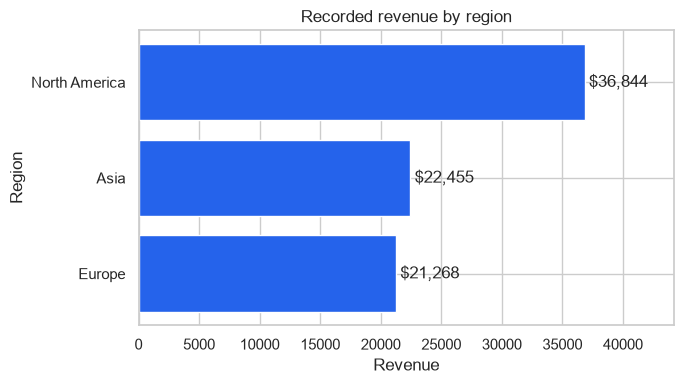

In [32]:
regional_revenue = sales_assignment.groupby('Region')['Total Revenue'].sum().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(regional_revenue.index, regional_revenue.values, color='#2563EB')
ax.bar_label(bars, labels=[f'${value:,.0f}' for value in regional_revenue.values], padding=3)
ax.set(title='Recorded revenue by region', xlabel='Revenue', ylabel='Region', xlim=(0, regional_revenue.max() * 1.2))
fig.tight_layout()
plt.show()


## 30. Choose Seaborn semantics carefully

**Task:** Plot unit price against total revenue, using product category as color and units sold as point size. Then state one limitation.

**Explain it like I am five:** Color gives dots team shirts and size gives them different backpacks. Too many signals can become noisy, so every mapping must help the question.

**Before running:** predict the important output shape, row count, or interpretation.


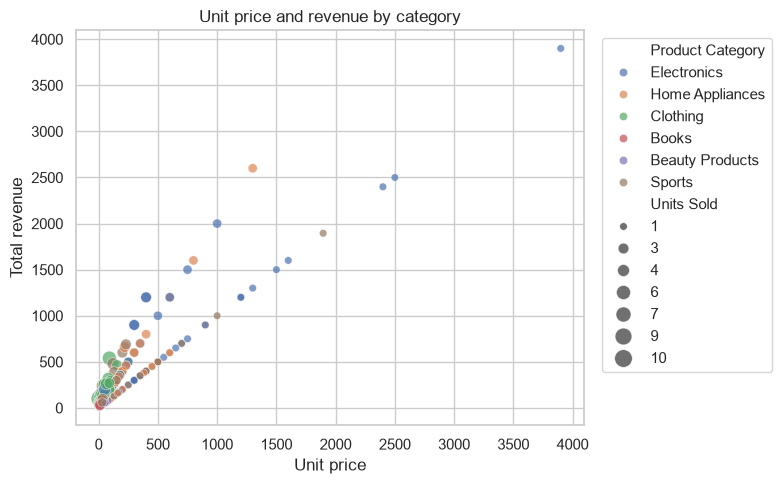

Limitation: revenue is mathematically affected by both unit price and units sold; the plot does not prove causation.


In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sales_assignment,
    x='Unit Price',
    y='Total Revenue',
    hue='Product Category',
    size='Units Sold',
    sizes=(30, 160),
    alpha=0.7,
    ax=ax
)
ax.set(title='Unit price and revenue by category', xlabel='Unit price', ylabel='Total revenue')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()

print("Limitation: revenue is mathematically affected by both unit price and units sold; the plot does not prove causation.")


# Easy revision cheat sheet

| Questions | Concepts |
|---|---|
| 1–3 | seeded random data, axes, broadcasting |
| 4–6 | clipping, conditional selection, missing numeric values |
| 7–10 | scaling safety, ranking positions, stacking, matrix multiplication |
| 11–15 | schemas, label/position indexing, strings, dates, duplicates |
| 16–18 | group filling, named aggregation, transform and group shares |
| 19–23 | pivot, melt, validated merge, unmatched keys, concat provenance |
| 24–27 | method chains, ordered categories, resampling, lagged windows |
| 28–30 | correlation sensitivity, honest charts, visual semantics |

## Core patterns

```python
# Reproducible NumPy
rng = np.random.default_rng(seed)

# Safe Pandas filtering
result = df.loc[(condition_one) & (condition_two), ['column_a', 'column_b']]

# Named group summary
report = df.groupby('key', as_index=False).agg(Total=('value', 'sum'))

# Group value aligned to every row
df['Group_Total'] = df.groupby('key')['value'].transform('sum')

# Audited join
merged = left.merge(right, on='key', validate='one_to_many', indicator=True)

# Past-only rolling feature
df['Past_Average'] = df['value'].shift(1).rolling(3).mean()

# Clear Matplotlib structure
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set(title='...', xlabel='...', ylabel='...')
plt.show()
```

**Final memory trick:** First protect meaning and correctness; then make the code shorter or the chart prettier.


## Next-step challenges

- Turn any five solutions into reusable functions with docstrings and type hints.
- Add one deliberate bad input to each and write a validation check.
- Solve questions 17–27 again using a different grouping or time period.
- Explain each final result in one sentence without mentioning code.
